In [3]:
import pandas as pd
import scipy.stats as st
import pingouin as pg
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np

# Задача 1

In [4]:
# загружаем данные с диска по регистрации
registration_data = pd.read_csv('/shared/problem1-reg_data.csv', sep=';')

In [5]:
# загружаем данные с диска по авторизации
authorization_data = pd.read_csv('/shared/problem1-auth_data.csv', sep=';')

In [6]:
# Переводим данные в дату
authorization_data['auth_date'] = pd.to_datetime(authorization_data['auth_ts'], unit='s')
registration_data['reg_date'] = pd.to_datetime(registration_data['reg_ts'], unit='s')

In [7]:
# посмотрим, как выглядят данные по регистрации
registration_data.head()

,reg_ts,uid,reg_date
0,911382223,1,1998-11-18 09:43:43
1,932683089,2,1999-07-22 22:38:09
2,947802447,3,2000-01-13 22:27:27
3,959523541,4,2000-05-28 14:19:01
4,969103313,5,2000-09-16 11:21:53


In [8]:
# удалим дубликаты, если они есть в данных. их не было
registration_data = registration_data.drop_duplicates()

In [9]:
# посмотрим общую информацию по данным по регистрации, нулевых значений нет
registration_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1000000 entries, 0 to 999999
Data columns (total 3 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   reg_ts    1000000 non-null  int64         
 1   uid       1000000 non-null  int64         
 2   reg_date  1000000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 30.5 MB


In [10]:
# посмотрим, как выглядят данные по авторизации
authorization_data.head()

,auth_ts,uid,auth_date
0,911382223,1,1998-11-18 09:43:43
1,932683089,2,1999-07-22 22:38:09
2,932921206,2,1999-07-25 16:46:46
3,933393015,2,1999-07-31 03:50:15
4,933875379,2,1999-08-05 17:49:39


In [11]:
# проверим, что в данных по авторизации действительно есть несколько строк для каких-либо uid
authorization_data.uid.value_counts()

2         1929
108       1397
158       1367
176       1331
191       1296
          ... 
158613       1
534808       1
534809       1
534810       1
158627       1
Name: uid, Length: 1000000, dtype: int64

In [12]:
# удалим дубликаты по авторизациям, если они есть в данных. их не было
authorization_data = authorization_data.drop_duplicates()

In [13]:
# посмотрим общую информацию по данным по авторизации
authorization_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9601013 entries, 0 to 9601012
Data columns (total 3 columns):
 #   Column     Dtype         
---  ------     -----         
 0   auth_ts    int64         
 1   uid        int64         
 2   auth_date  datetime64[ns]
dtypes: datetime64[ns](1), int64(2)
memory usage: 293.0 MB


In [14]:
# проверяем, что нулевых значений нет 
authorization_data.isnull().sum()

auth_ts      0
uid          0
auth_date    0
dtype: int64

In [15]:
# посмотрим, диапазон дат, которые есть в данных по авторизации
authorization_data['auth_date'].describe(datetime_is_numeric=True)

count                          9601013
mean     2019-01-29 16:12:06.254851584
min                1998-11-18 09:43:43
25%                2018-06-07 12:40:47
50%                2019-07-31 12:43:16
75%                2020-04-02 10:25:21
max                2020-09-23 15:17:24
Name: auth_date, dtype: object

In [16]:
def retention_function(authorization_data, registration_data, date_start, date_end):
    '''
    Возвращает таблицу с показателями retention возвращения в игру после регистрации по дням за определенный период.
    
    Параметры:
    authorization_data (DataDrame): данные по авторизации, первый столбец reg_ts, второй столбец uid, 
    registration_data (DataDrame): данные по регистрации, первый столбец auth_ts, второй столбец uid,
    date_start(str) : дата первого дня для анализа в формате "YYYY-MM-DD". Должна быть раньше, чем date_end, 
    date_end (str): дата последнего дня для анализа в формате "YYYY-MM-DD". Должна быть позже, чем date_start.
    
    Возвращаемое значение: 
    retention_matrix : таблица с показателями ретеншн в долях по дням за определенный период
   
    '''
    
    # Переводим данные в дату
    authorization_data['auth_date'] = pd.to_datetime(authorization_data['auth_ts'], unit='s')
    registration_data['reg_date'] = pd.to_datetime(registration_data['reg_ts'], unit='s')
    
    # Выбираем отрезок времени, который будем анализировать
    reg_data = registration_data.query('@date_end > reg_date > @date_start')
    auth_data = authorization_data.query(' @date_end > auth_date > @date_start')

    # Объединяем данные по регистрации с данными по авторизации игроков
    data_copy = pd.merge(reg_data, auth_data, on='uid', how='left')
    
    # Извлекаем день авторизации
    
    data_copy['play_period_day'] = data_copy['auth_date'].dt.to_period('D')
    
    # Присваиваем когорты на основе даты первого действия для каждого пользователя
    data_copy['cohort_day'] = data_copy.groupby('uid')['reg_date'].transform('min').dt.to_period('D')
    
    # Рассчитываем номер периода по дням
    data_copy['period_number_day'] = (data_copy['auth_date'] - data_copy['reg_date']).dt.days
    
    # Агрегируем данные по когортам и рассчитанному номеру периода
    df_cohort = data_copy.groupby(['cohort_day', 'period_number_day']).agg(n_customers=('uid', 'nunique')).reset_index()
    
    # Создаем сводную таблицу для когортного анализа
    cohort_pivot = df_cohort.pivot_table(index='cohort_day', columns='period_number_day', values='n_customers')
    
    # Рассчитываем размеры когорт (первый столбец сводной таблицы)
    cohort_size = cohort_pivot.iloc[:, 0]
    
    # Вычисляем коэффициенты удержания, деля на размер когорты
    retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
    
    return retention_matrix

In [17]:
retention_matrix = retention_function(authorization_data, registration_data, "2019-01-01", "2019-02-01")
retention_matrix

period_number_day,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
cohort_day,,,,,,,,,,,,,,,,,,,,,
2019-01-01,1.0,0.034305,0.048027,0.046312,0.053173,0.075472,0.078902,0.048027,0.053173,0.060034,...,0.030875,0.042882,0.039451,0.036021,0.030875,0.046312,0.037736,0.030875,0.027444,0.012007
2019-01-02,1.0,0.036021,0.051458,0.044597,0.056604,0.070326,0.063465,0.056604,0.029160,0.049743,...,0.041166,0.037736,0.025729,0.030875,0.029160,0.036021,0.029160,0.018868,0.017153,NaN
2019-01-03,1.0,0.030769,0.032479,0.058120,0.061538,0.054701,0.080342,0.029060,0.035897,0.051282,...,0.041026,0.034188,0.022222,0.049573,0.032479,0.042735,0.032479,0.011966,NaN,NaN
2019-01-04,1.0,0.044444,0.041026,0.046154,0.058120,0.064957,0.078632,0.034188,0.054701,0.052991,...,0.041026,0.034188,0.032479,0.037607,0.047863,0.037607,0.011966,NaN,NaN,NaN
2019-01-05,1.0,0.032423,0.046075,0.047782,0.066553,0.085324,0.071672,0.049488,0.061433,0.044369,...,0.058020,0.035836,0.037543,0.025597,0.046075,0.018771,NaN,NaN,NaN,NaN
2019-01-06,1.0,0.034014,0.049320,0.047619,0.044218,0.064626,0.066327,0.052721,0.049320,0.039116,...,0.037415,0.045918,0.034014,0.040816,0.013605,NaN,NaN,NaN,NaN,NaN
2019-01-07,1.0,0.035714,0.035714,0.059524,0.051020,0.086735,0.083333,0.039116,0.059524,0.035714,...,0.039116,0.035714,0.037415,0.011905,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-08,1.0,0.059423,0.033956,0.054329,0.061121,0.074703,0.084890,0.042445,0.054329,0.040747,...,0.045840,0.027165,0.025467,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-09,1.0,0.020339,0.045763,0.038983,0.057627,0.054237,0.061017,0.047458,0.057627,0.047458,...,0.033898,0.023729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


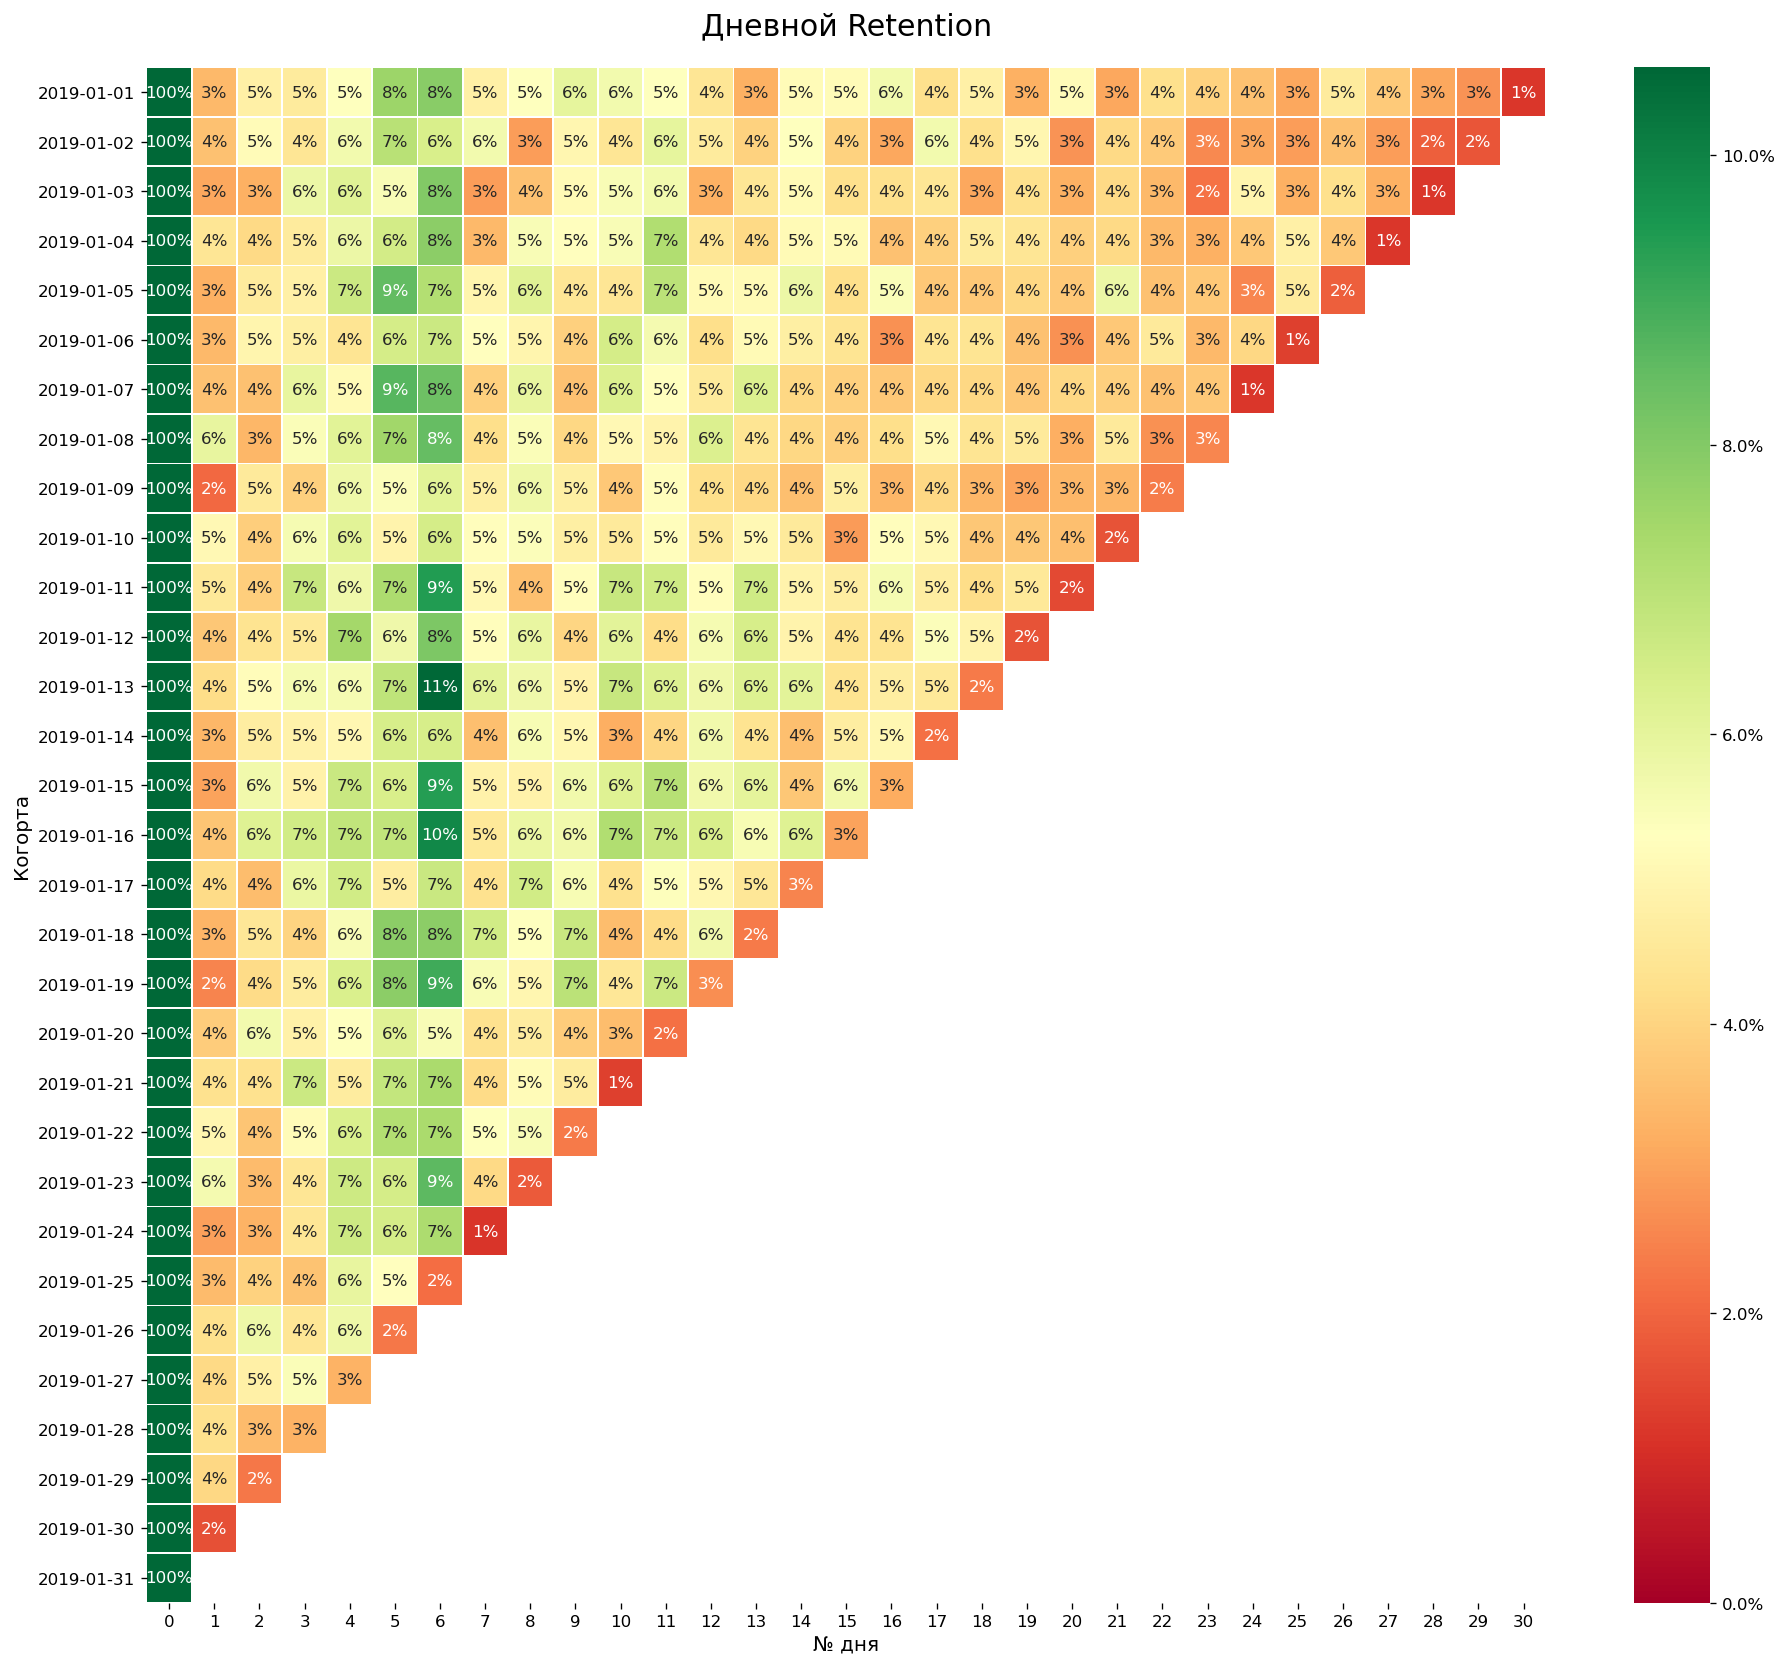

In [18]:
# Строим график
plt.figure(figsize=(16, 14), dpi=120)

# Находим самый большой ретеншн в таблице, чтобы в разбивке по цветам это было максимальное значение
vmax = retention_matrix.iloc[:, 1:].max().max()

sns.heatmap(
    retention_matrix,
    mask=retention_matrix.isnull(),
    annot=True,
    fmt=".0%",
    cmap="RdYlGn",
    vmin=0,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'format': PercentFormatter(1, decimals=1)}
)

plt.title("Дневной Retention", fontsize=18, pad=20)
plt.xlabel("№ дня", fontsize=12)
plt.ylabel("Когорта", fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# Задача 2

Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений.  
- Известно, что ARPU в тестовой группе (b) выше на 5%, чем в контрольной. 
- При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

In [20]:
# импортируем файл
ex2 = pd.read_csv('Проект_1_Задание_2.csv', sep=';')

Сначала проанализируем данные по средней выручке (то есть ARPU)

#### Построим графики распределения по выручке

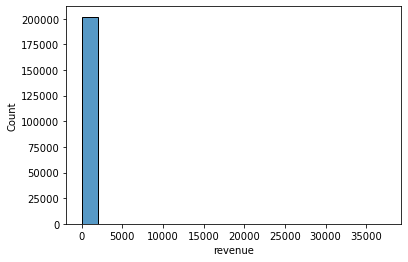

In [21]:
# распределение выручки по группе a
sns.histplot(data=ex2.query('testgroup =="a"'), x="revenue")

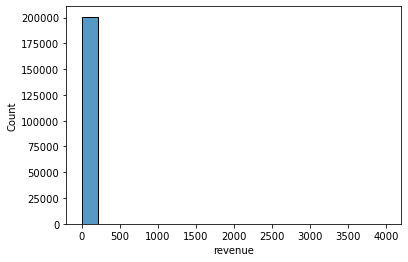

In [22]:
# распределение выручки по группе b
sns.histplot(data=ex2.query('testgroup =="b"'), x="revenue")

По графикам видна сильная ассиметрия вправо. Очевидно, что распределение ненормальное, позже докажем это стат тестами

Также посмотрим на отдельные показатели по группам

In [23]:
# размер выручки по группам
ex2.groupby('testgroup', as_index=False).revenue.sum()

,testgroup,revenue
0,a,5136189
1,b,5421603


In [24]:
# количество пользователей по группам
ex2.groupby('testgroup', as_index=False).user_id.count()

,testgroup,user_id
0,a,202103
1,b,202667


In [25]:
# считаем разницу наблюдений между контрольной и тестовой группой. в целом это 0.28% от общего числа пользователей
# контрольной группы, что может быть незначительным в контексте A/B тестирования, поэтому ей можно пренебречь
202667 - 202103

564

In [26]:
# разница средних значений выручки по группам
ex2.groupby('testgroup', as_index=False).agg({'revenue': 'mean'})

,testgroup,revenue
0,a,25.413720
1,b,26.751287


Разница в средних значениях ARPU в выборках есть, но она небольшая. Вопрос в том, является ли она статистически значимой?

Сформулируем гипотезы:
- H0: Разница между средними ARPU двух ГС равна 0 (ARPU_a = ARPU_b)
- H1: Разница между средними ARPU двух ГС не равна 0 

In [27]:
# достаём значения двух групп
a = ex2.query("testgroup == 'a'").revenue
b = ex2.query("testgroup == 'b'").revenue

Для проведения t-теста для сравнения средних нужно проверить несколько допущений:

#### Проверка равенства дисперсий
- H0 : Разницы между дисперсиями контрольной и тестовой группами нет
- H1 : Разница между дисперсиями контрольной и тестовой группами есть

In [28]:
st.levene(a, b)

LeveneResult(statistic=0.3896289474701388, pvalue=0.5324948591043842)

In [29]:
pg.homoscedasticity(data=ex2, dv="revenue", group="testgroup")

,W,pval,equal_var
levene,0.389629,0.532495,True


Так как p-value>0.05, то мы не можем отклонить нулевую гипотезу, поэтому **дисперсии равны**. Одно из допущений для проведения t-теста подтвердилось.

#### Нормальность данных
Так как у нас очень большие выборки (> 5 000), то будем использовать тест Д'Агостино-Пирсона  

- H0 : ГС, из которой взята эта выборка, распределена нормально   
- H1 : ГС, из которой взята эта выборка, распределена не нормально

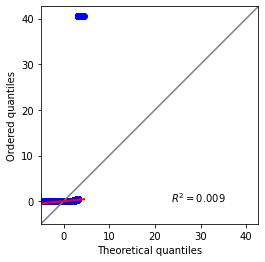

In [30]:
# посмотрим на qq-графики
pg.qqplot(a)

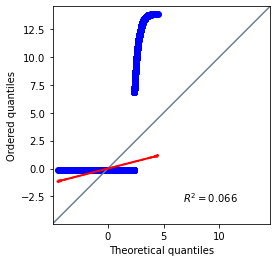

In [31]:
pg.qqplot(b)

In [32]:
pg.normality(data=ex2, dv="revenue", group="testgroup", method="normaltest")

,W,pval,normal
testgroup,,,
b,326622.395409,0.0,False
a,585152.731273,0.0,False


P-value нулевое, поэтому мы отклоняем нулевую гипотезу и можно сделать вывод о том, что **данные распределены ненормально**
На ненормальном распределении т-тест можно использовать только с большим количеством оговорок, поэтому сделаем наше распределение нормальным с помощью логарифмирования

Так как логарифмировать 0 нельзя, то в исходные выборки для сравнения мы возьмем только тех клиентов, которые совершили покупку

In [33]:
# оставляем только платящих клиентов
profit_clients = ex2.query('revenue>0')

In [34]:
# оставляем данные только по купившим клиентам по группам
control_a = ex2.query("testgroup == 'a' & revenue > 0")[['revenue']]
test_b = ex2.query("testgroup == 'b' & revenue > 0")[['revenue']]

/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


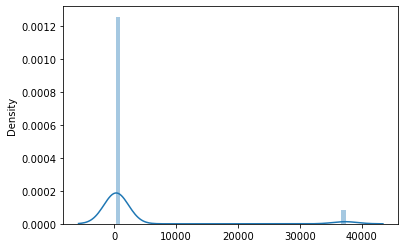

In [35]:
# посмотрим графики по клиентам, которые заплатили
sns.distplot(control_a)

/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


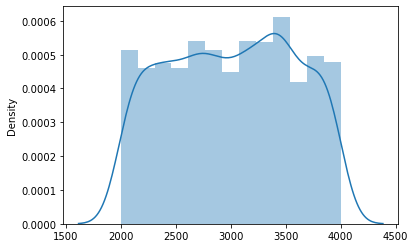

In [36]:
sns.distplot(test_b)

Эти графики уже выглядят более понятными, но симметричности все равно нет

In [37]:
# логарифмируем значения выручки
control_a['log'] = np.log(control_a.revenue)
test_b['log'] = np.log(test_b.revenue)

In [38]:
# достаём значения выручки по логарифму для двух групп
a_log = control_a.log
b_log = test_b.log

/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


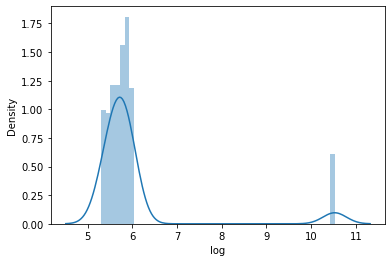

In [39]:
# построим графики по логарифмированным данным 
sns.distplot(a_log)

/opt/conda/lib/python3.9/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


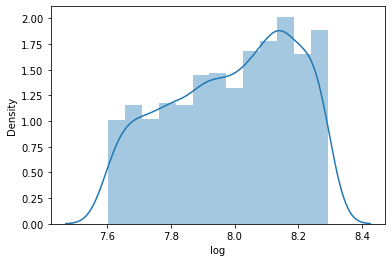

In [40]:
sns.distplot(b_log)

#### Проверка нормальности логарифмированных данных
- H0 : ГС, из которой взята эта выборка, распределена нормально   
- H1 : ГС, из которой взята эта выборка, распределена не нормально

In [41]:
print(st.shapiro(a_log))

ShapiroResult(statistic=0.409080281305897, pvalue=6.7488471669664995e-62)


In [42]:
print(st.shapiro(b_log))

ShapiroResult(statistic=0.9519462976026036, pvalue=6.975234507912318e-24)


Так как p-value < 0.05, отклоняем нулевую гипотезу. Данные все еще не нормальные, поэтому попробуем метод бутстрапа

#### Контекст ситуации по платящим пользователям:  
- В группе А мы видим, что большее количество покупателей (1805) приносят выручку в диапазоне 200-400 ден.ед. Но также есть небольшое количество пользователей, которые делают большие покупки на сумму 37 000 - 38 000, при этом несмотря на то, что на графике их меньше по количеству (123), они приносят выручки в 8 раз больше. График выглядит супер ассиметрично, и основная выручка достигается за счет клиентов, которые делают "крупные заказы". Среднее очень чувствительно к экстремальным значениям. В группе А эти 123 крупных платежа сильно тянут среднее вверх, поэтому оно не отражает «типичное» поведение большинства покупателей.
- В группе B наблюдается более сглаженная картинка, выручка на 1 клиента располагается в диапазоне от 2 000 до 4 000 ден. ед. Общая выручка осталась на том же уровне, однако теперь выручка не так сильно зависит от клиентов с крупными заказами. Доход распределен более равномерно. 

Исходя из контекста ситуации кроме бутстрапа средних также сделаем бутстрап медиан

#### Бутстрап

In [109]:
# пишем функцию для бутстрапа для повторения 10 000 раз

def boot_func(series, stat, reps=10000):

    boot_data = []  # складываем сюда результаты вычислений
    
    # повторяем процедуру n раз
    for _ in range(reps):

        sample_data = series.sample(frac=1, replace=True)  # генерируем бут-выборку
        sample_stat = stat(sample_data)  # считаем статистику
        boot_data.append(sample_stat)  # добавляем её в список

    return (np.array(boot_data))

In [110]:
# формируем данные для бут-распределения по группе a
a_mean = boot_func(a, np.mean)

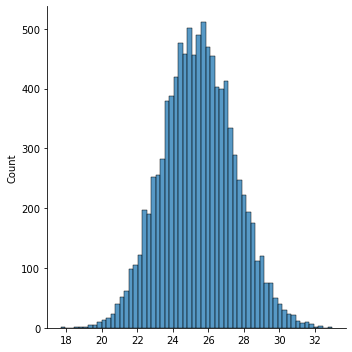

In [111]:
# строим бут-распределение на основе данных по группе a, визуально похоже на нормальное
sns.displot(a_mean)

#### Проверка нормальности бутстрапированных данных  
Поскольку в бутстрэпе используем 10 000 сэмплов, тест Д'Агостино-Пирсона будет иметь очень высокую мощность, т. е. реагировать даже на микроскопические отклонения от нулевой гипотезы. Для уменьшения вероятности ложноположительных результатов, снизим уровень значимости до 0.001

- H0 : ГС, из которой взята эта выборка, распределена нормально   
- H1 : ГС, из которой взята эта выборка, распределена не нормально

In [112]:
# проверяем нормальность данных по тесту Д'Агостино-Пирсона. 
print(st.normaltest(a_mean))

NormaltestResult(statistic=11.687731429976587, pvalue=0.0028976195758079063)


p-value > 0.001, поэтому принимаем нулевую гипотезу, данные нормальные. 

Проверка нормальности после бутстрапа необязательна, так как это непараметрический метод. 
Однако мы делаем бутстрап средних и исходя из ЦПТ бутстрапированные данные должны по идее стремиться к нормальному распределению. А если данные нормальны, то мы можем использовать стандартные формулы для расчета доверительных интервалов (+-1,96σ), но здесь это не используется 


Найдем доверительные интервалы через квантили для эксперимента со средними по группе а

In [113]:
# верхняя граница доверительного интервала
pd.Series(a_mean).quantile(0.975)

29.482470200838186

In [114]:
# нижняя граница доверительного интервала
pd.Series(a_mean).quantile(0.025)

21.582320277284353

**Вывод**: В группе A средняя выручка (средний доход на одного пользователя) равняется 25,41, и в долгосрочной перспективе построенные таким же образом доверительные интервалы будут содержать в себе среднее ГС в 95% случаев

In [117]:
b_mean = boot_func(b, np.mean)

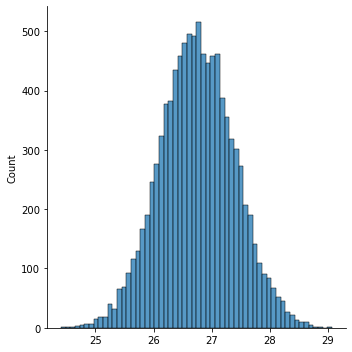

In [119]:
# строим бутраспределение на основе данных по группе b, визуально похоже на нормальное
sns.displot(b_mean)

In [120]:
# верхняя граница доверительного интервала
pd.Series(b_mean).quantile(0.975)

28.027860233782512

In [121]:
# нижняя граница доверительного интервала
pd.Series(b_mean).quantile(0.025)

25.498971958927697

**Вывод**: В группе B средняя выручка (средний доход на одного пользоввателя) равняется 26,75, и в долгосрочной перспективе построенные таким же образом доверительные интервалы будут содержать в себе среднее ГС в 95% случаев

### Вывод по средней выручке: 
На основании анализа доверительных интервалов для средних значений контрольной и тестовой групп, мы наблюдаем, что доверительный интервал тестовой группы (25,5-28,04) полностью входит в доверительный интервал контрольной группы (21,44-29,5). Это указывает на отсутствие статистически значимых различий между группами на уровне значимости 0,05. 

#### Бутстрап разницы средних

In [116]:
# пишем функцию для бутстрапа разницы средних

def two_sample_boot(x, y, stat, reps=5000):

    boot_data = []

    for _ in range(reps):

        sample_x = x.sample(frac=1, replace=True)
        sample_y = y.sample(frac=1, replace=True)
        sample_stat_diff = stat(sample_x) - stat(sample_y)
        boot_data.append(sample_stat_diff)

    return (np.array(boot_data))

In [118]:
# формируем данные для бут-распределения разницы средних
diff = two_sample_boot(a, b, np.mean)

In [122]:
# верхняя граница доверительного интервала
upper_bound = pd.Series(diff).quantile(0.975)
upper_bound

2.88989766648906

In [123]:
# нижняя граница доверительного интервала
lower_bound = pd.Series(diff).quantile(0.025)
lower_bound

-5.62108173452421

### Вывод по средней выручке по бутстрапу разницы средних:

(-5,62; 2,89) - доверительный интервал для разницы средних, построенный с помощью бутстрапа. Поскольку этот интервал включает 0, мы не можем отклонить нулевую гипотезу о равенстве средних ARPU на уровне значимости 0,05. Следовательно, статистически значимой разницы между группами нет.

#### Бутстрап разницы медиан
Здесь будем использовать только платящих пользователей, так как для всех медиана будет равна 0

In [137]:
# посмотрим медину (50% квантиль) для группы А
control_a.revenue.describe()

count     1928.000000
mean      2663.998444
std       9049.039763
min        200.000000
25%        257.000000
50%        311.000000
75%        361.000000
max      37433.000000
Name: revenue, dtype: float64

In [138]:
# посмотрим медиану (50% квантиль) для группы B. разница между медианами видна и на глаз, но проверим статистически
test_b.revenue.describe()

count    1805.000000
mean     3003.658172
std       572.619709
min      2000.000000
25%      2513.000000
50%      3022.000000
75%      3478.000000
max      4000.000000
Name: revenue, dtype: float64

In [126]:
# формируем данные для бут-распределения разницы медиан по платящим пользователям
diff_median = two_sample_boot(control_a.revenue, test_b.revenue, np.median)

In [139]:
# верхняя граница доверительного интервала
upper_bound_median = pd.Series(diff_median).quantile(0.975)
upper_bound_median

-2657.0

In [140]:
# нижняя граница доверительного интервала
lower_bound_median = pd.Series(diff_median).quantile(0.025)
lower_bound_median

-2761.0

#### Вывод по бутстрапу разницы медиан
(-2 657; -2 761) - доверительный интервал для разницы медиан, построенный с помощью бутстрапа. Поскольку этот интервал не включает 0, между группами есть статически значимая разница медиан. Медиана группы A ниже медианы группы B

#### Теперь сравним данные по конверсиям в платящего пользователя:

In [52]:
conversion = ex2.groupby('testgroup').agg(
    paid_users=('revenue', lambda x: (x > 0).sum()),  # Количество платящих (revenue > 0)
    non_paid_users=('revenue', lambda x: (x == 0).sum()),  # Количество неплатящих (revenue = 0)
)

In [53]:
conversion

,paid_users,non_paid_users
testgroup,,
a,1928,200175
b,1805,200862


- H0: Конверсия в платящих пользователей не зависит от группы (то есть, конверсии в группах a и b статитически не различимы)  
- H1: Конверсия в платящих пользователей  зависит от группы (то есть, конверсии в группах a и b статистически различимы)

In [54]:
# проводим тест хи-квадрат
st.chi2_contingency(conversion)

Chi2ContingencyResult(statistic=4.374729521260405, pvalue=0.03647561892312613, dof=1, expected_freq=array([[  1863.89924896, 200239.10075104],
       [  1869.10075104, 200797.89924896]]))

### Вывод по конверсии в платящего пользователя
Так как p-value по результатам теста хи-квадрат меньше 0,05, то можно отвергнуть нулевую гипотезу. Значит, статистически значимые различия в конверсии между группами A и B есть. Группа A отработала лучше

# Вывод по задаче 2
- По ARPU по результатам бутстрапа разницы средних статистически значимых различий не было. 
- По результатам бутстрапа разницы медиан медианная выручка на одного платящего пользователя была статистически выше в группе B, что говорит о более равномерной отдаче от большинства клиентов
- По результатам теста хи-квадрат по конверсии в платящего пользователя лучше отработала группа A

Модель A генерирует высокую общую выручку за счет небольшого числа крупных клиентов, но это повышает риск зависимости от отдельных пользователей и колебаний дохода. При этом для мобильных игр нормальна ситуация, когда основную выручку делают киты.

Модель B более устойчива: доход распределен равномернее среди платящих клиентов, что снижает риски и делает финансовые результаты более стабильными. Однако с учетом сферы компании, мобильная игра, не рекомендуется раскатывать модель B.

# Задача 3
В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

## Первая ситуация:
**с помощью каких метрик можно оценить результаты события, где для получения награды требуется пройти ряд уровней за определенное время**

**Целевые метрики**:
- ARPU - чтобы понимать, повлияло ли событие на уровень покупок в игре, так как часто события стимулируют донаты. Может быть, кто-то покупал дополнительные игровые деньги, чтобы получить "уникальные" предметы во время события. Также можно сравнить доход во время события по отношению к периоду "до".
- Post-Event Retention - остались ли игроки активными после окончания события? Прямое отражение долгосрочной ценности продукта.
- Среднее время, проведенное в игре - чтобы понимать стали ли пользователи больше времени проводить в игре. 

**Прокси-метрики**:
- Среднее количество входов в игру в день - стали ли игроки чаще заходить в игру за время события. 
- DAU (количество уникальных игроков за сутки) -  посмотреть, как менялось во время события по отношению к предыдущим периодам. Покажет, как событие повлияло на аудиторию.
- Reactivation Rate - сколько неактивных ранее игроков вернулись из-за ивента
- Число сыгранных уровней в день на игрока - влияет на среднее время, проведенное в игре. Чем больше она, тем больше время, проведенное в приложении.
- Среднее количество успешно пройденных одним игроком уровней - чтобы понимать, после какого уровня пропадает интерес/мотивация. Оценка вовлеченности пользователей. 
- % игроков, получивших уникальные бонусы - чтобы понимать уровень сложности события и получения награды, что влияет на мотивацию игроков. Плюс дает понимание, какое количество людей скорее всего удовлетворены событием и вернутся в приложение.
- Воронка по уровням игры до получения награды с количеством активных пользователей - уровень оттока клиентов на разных уровнях, чтобы использовать эти данные в проведении дальнейших событий.
- Среднее время, проведенное в игре, за которое игроки получают награду - чтобы понимать оптимальную длительность события
- Конверсия в платящих пользователей

**Барьерные метрики:**
- % оттока пользователей среди участников события - если сильно большой, то стоит приостановить событие

## Вторая ситуация:
**с помощью каких метрик можно оценить результаты события, где для получения награды требуется пройти ряд уровней за определенное время, но при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад**

Да, набор метрик изменится, так как механика отката будет негативно влиять на психологию игрока, поэтому важно будет сосредоточиться на выявлении его негативного опыта в момента отката и понимании, как он влияет на дальнейшее поведение игрока в игре

**Целевые метрики**: 
- Конверсия в платящих пользователей - отслеживание денежного успеха механики, вероятно, может вырасти, так как пользователи захотят быть более подготовленными к уровням, чтобы не откатываться назад. 
- Post-Event Retention - остались ли игроки активными после окончания события? Прямое отражение долгосрочной ценности продукта.  - % игроков, успешно завершивших событие - чтобы понимать, насколько сильно оно падает относительно предыдущих событий, и если он сильно низкий, это вероятно, будет говорить о неудовлетворенности пользователей

Среднее время, проведенное в игре, теперь не будет так объективно отражать ситуацию, как в предыдущем варианте, потому что многие пользователи могут начать "отыгрываться" от предыдущих откатов, а кто-то наоборот очень сильно расстроится и уйдет, поэтому метрика не даст четкого понимания о результатах этого события и ее не стоит оставлять в целевых.


**Прокси-метрики**:

- % игроков, которые хотя бы раз откатились назад
- % игроков, достигших уникального бонуса без единого отката
- Среднее количество уровней, потерянных игроком - сколько уровней в среднем игрок теряет за событие
- Частота откатов - сколько раз в среднем игрок сталкивался с откатом за время события
- CSAT - посколько многие пользователи столкнутся с откатом назад, важно оценить их уровень удовлетворенности, чтобы понимать обратную связь от пользователей
- ARPU - оцениваем динамику по отношению к предыдущим событиям, чтобы понимать, как эта метрика повлияет на покупки пользователей в игре.

**Барьерные метрики**:
- Churn Rate - становится наиболее важно метрикой для отслеживания. Сколько игроков больше не вернулись в игру во время события после неудачной попытки выполнения уровня и отката? (Если большое количество пользователей не вернулись в игру после первого отката, то это большая проблема для дальнейшего удержания пользователей и событие не стоит продолжать) И сколько игроков, столкнувшихся с откатом, не вернулись в игру в течение первой недели после события?
- Количество игроков, отказавшихся от события после первой неудачи
- DAU (количество уникальных игроков за сутки) - если начинает сильно падать, то это также сигнал о том, что игроки не возвращаются в игру из-за страха потерять свои уровни.